<a href="https://colab.research.google.com/github/Dorkom/Automatizaciones_google_colab/blob/main/PRODUCCION_visual_to_markdown_rag_batch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ Visual-to-Markdown · Batch Automático · RAG
### Convierte todas las páginas del PDF en un único `.md` — sin intervención manual

---

**Flujo:**
```
PDF  →  [PyMuPDF]  →  N imágenes  →  [OpenAI Vision · loop]  →  N Markdown  →  manual_rag.md
```

**Ejecución:** Secciones 0 → 1 → 2 → 3 → 4 → 5 → 6 (en orden, una vez cada una).  
**Opcional antes del batch:** Sección 5.0 para probar el prompt en una sola página.


## 📦 Sección 0 — Instalación

In [ ]:
!pip install -q pymupdf openai pillow
print("✅ Dependencias instaladas.")


✅ Dependencias instaladas.


## ⚙️ Sección 1 — Configuración

> **Prerequisito:** configura tu API key en **Colab → Secrets** (🔑 panel izquierdo):
> - `OPENAI_ULIMA` → clave corporativa OpenAI
>
> Si tu endpoint corporativo tiene URL personalizada, descomenta `OPENAI_BASE_URL`.


In [ ]:
import fitz                 # PyMuPDF
from openai import OpenAI
from PIL import Image
import base64, io, os, json, time
from datetime import datetime
from IPython.display import display, Markdown, HTML, Image as IPImage
from google.colab import userdata, files

# ── API Key ───────────────────────────────────────────────────
OPENAI_API_KEY = userdata.get('OPENAI_ULIMA')

# ⚠️  Endpoint corporativo personalizado (descomenta si aplica):
# OPENAI_BASE_URL = "https://tu-endpoint-corporativo.com/v1"
# client = OpenAI(api_key=OPENAI_API_KEY, base_url=OPENAI_BASE_URL)
client = OpenAI(api_key=OPENAI_API_KEY)

# ── Modelo ────────────────────────────────────────────────────
MODEL = "gpt-5.2"          # Alt: "gpt-5.4-mini" (más barato/rápido)

# ── Parámetros de conversión PDF ──────────────────────────────
PDF_DPI   = 150    # 150=rápido | 200=balance | 300=máxima calidad
MAX_WIDTH = 1600   # Ancho máx. enviado a la API (px)

# ── Parámetros del batch ──────────────────────────────────────
MAX_TOKENS          = 2000  # Tokens máximos por respuesta
DELAY_BETWEEN_PAGES = 1     # Segundos de pausa entre páginas (evita rate-limit)
MAX_RETRIES         = 3     # Intentos ante error de API antes de marcar como fallida
RETRY_DELAY         = 8     # Segundos de espera entre reintentos

print("✅ Configuración cargada.")
print(f"   Modelo   : {MODEL}")
print(f"   DPI      : {PDF_DPI}  |  Ancho máx: {MAX_WIDTH}px")
print(f"   Pausa    : {DELAY_BETWEEN_PAGES}s entre páginas  |  Reintentos: {MAX_RETRIES}")


✅ Configuración cargada.
   Modelo   : gpt-5.2
   DPI      : 150  |  Ancho máx: 1600px
   Pausa    : 1s entre páginas  |  Reintentos: 3


## ✏️ Sección 2 — Prompt del Sistema *(editable)*

> 🔧 Ajusta este prompt antes de lanzar el batch.  
> Si usas la **Sección 5.0** (prueba en una página), calibra aquí antes de correr todo.


In [ ]:
SYSTEM_PROMPT = '''Eres un experto en documentación técnica universitaria.
Analiza la imagen de esta página de manual de usuario y conviértela COMPLETAMENTE
a Markdown estructurado, optimizado para sistemas RAG (Retrieval-Augmented Generation).

REGLAS OBLIGATORIAS:
1. Transcribe LITERALMENTE el texto de instrucciones visible en la imagen, sin omitir nada.
2. Para cada captura de pantalla o imagen de interfaz que aparezca, describe:
   - ÚNICAMENTE los elementos relevantes para ejecutar el paso: botones, menús,
     campos, íconos, etiquetas y textos con los que el usuario debe interactuar
     o que le sirven de referencia visual para ubicarse.
   - NO incluyas elementos de contexto genérico que no aporten a la acción
     (título de pestaña del navegador, URL si ya aparece en la instrucción,
     logos decorativos, créditos, íconos de accesibilidad, elementos fuera del
     área de atención del paso).
   - TODAS las anotaciones manuales presentes en la imagen:
     * Flechas: color, dirección y elemento exacto que señalan.
     * Círculos o recuadros de color: qué elemento rodean o destacan.
     * Texto superpuesto sobre la captura: transcribir literalmente.
   - La acción concreta que debe ejecutar el usuario en ese paso.
3. Conserva la numeración original de pasos si existe en el manual.
4. Usa EXACTAMENTE esta estructura para cada paso identificado:

## Paso N: [título descriptivo del paso]

**Instrucción:** [texto literal del manual, tal como aparece]

**Descripción de la interfaz:**
- [elemento relevante 1: qué es y dónde está]
- [elemento relevante 2: qué es y dónde está]

**Anotaciones visuales:** [descripción detallada: colores, posición y qué señalan]

**Acción requerida:** [descripción exacta de lo que hace el usuario: clic en X, escribir Y, etc.]

---

5. Al FINAL de la página incluye obligatoriamente esta sección:

## Palabras clave
[lista de términos relevantes separados por comas: nombre del portal, acciones,
secciones de interfaz, nombres de botones, URL, rol del usuario]

CRITERIO DE RELEVANCIA PARA "Descripción de la interfaz":
Incluye un elemento si cumple al menos una de estas condiciones:
  ✓ El usuario debe hacer clic, escribir o interactuar con él en este paso.
  ✓ Es una referencia visual necesaria para que el usuario se ubique en la pantalla
    (ej: "barra inferior de color naranja" ayuda a encontrar el botón MI ULIMA).
  ✓ Es mencionado explícitamente en la instrucción del paso.

Omite un elemento si:
  ✗ Solo describe el entorno general sin guiar la acción (título de pestaña,
    URL ya citada, logos del sitio, ícono de accesibilidad, elementos decorativos).
  ✗ Es un ítem de una lista larga donde solo uno es relevante: menciona solo ese ítem
    y el contexto mínimo de la lista (ej: "entre los enlaces de la barra naranja: MI ULIMA").

RESTRICCIONES ESTRICTAS:
- Responde ÚNICAMENTE con Markdown puro. Sin texto introductorio, sin meta-comentarios,
  sin bloques de código envolventes.
- NO inventes información que no esté visualmente presente en la imagen.
- Si hay texto ilegible en la imagen, escribe: [TEXTO ILEGIBLE].
- Si una captura de pantalla es pequeña o de baja resolución, descríbela con lo que
  puedas distinguir y añade: [RESOLUCIÓN LIMITADA — descripción aproximada].
'''

print(f"✅ Prompt cargado ({len(SYSTEM_PROMPT):,} caracteres).")


✅ Prompt cargado (3,246 caracteres).


## 📄 Sección 3 — Carga del PDF y Conversión a Imágenes

Elige **una** de las dos opciones de carga y luego ejecuta la celda de conversión.


### 3a — Opción A: Subir desde tu computador

In [ ]:
print("Selecciona el archivo PDF:")
uploaded = files.upload()
PDF_PATH = list(uploaded.keys())[0]
print(f"\n📄 Cargado: {PDF_PATH}")


Selecciona el archivo PDF:


IndexError: list index out of range

### 3b — Opción B: Cargar desde Google Drive *(descomenta para usar)*

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# PDF_PATH = "/content/drive/MyDrive/RUTA/manual.pdf"  # ← Ajusta
# print(f"📄 Desde Drive: {PDF_PATH}")


### 3c — Conversión PDF → Imágenes + Vista general

📑 17 páginas convertidas  (DPI=150 · ancho máx=1600px)



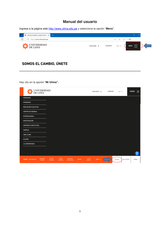
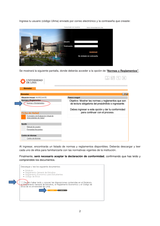
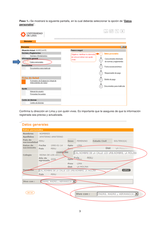
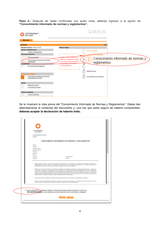
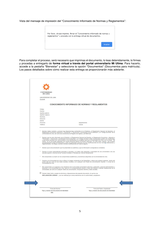
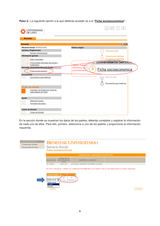
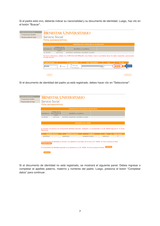
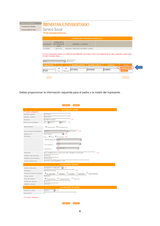
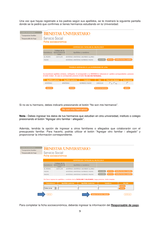
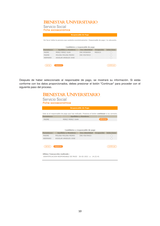
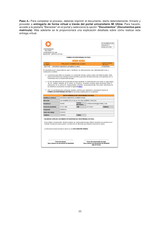
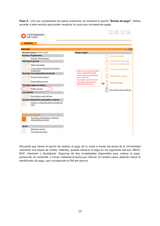
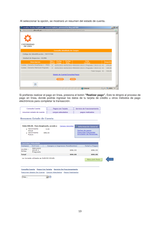
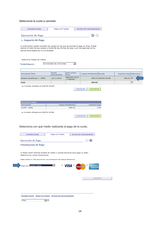
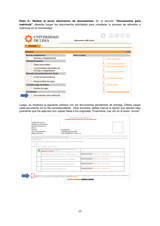
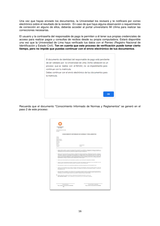
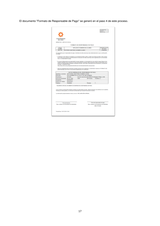

In [ ]:
# ── Utilidades de imagen ──────────────────────────────────────
def img_to_bytes(img: Image.Image) -> bytes:
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return buf.getvalue()

def img_to_b64(img: Image.Image) -> str:
    return base64.b64encode(img_to_bytes(img)).decode()

# ── Conversión ────────────────────────────────────────────────
def convert_pdf_to_images(pdf_path: str, dpi: int = 150,
                           max_width: int = 1600) -> list:
    '''Convierte el PDF a una lista de PIL.Image, una por página.'''
    doc    = fitz.open(pdf_path)
    images = []
    mat    = fitz.Matrix(dpi / 72, dpi / 72)
    for i in range(len(doc)):
        pix = doc[i].get_pixmap(matrix=mat, alpha=False)
        img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
        if img.width > max_width:
            ratio = max_width / img.width
            img   = img.resize((max_width, int(img.height * ratio)), Image.LANCZOS)
        images.append(img)
    doc.close()
    return images

pages = convert_pdf_to_images(PDF_PATH, dpi=PDF_DPI, max_width=MAX_WIDTH)
print(f"📑 {len(pages)} páginas convertidas  (DPI={PDF_DPI} · ancho máx={MAX_WIDTH}px)")

# ── Galería de miniaturas ─────────────────────────────────────
cards = []
for i, img in enumerate(pages):
    tw    = 160
    ratio = tw / img.width
    thumb = img.resize((tw, int(img.height * ratio)), Image.LANCZOS)
    buf   = io.BytesIO(); thumb.save(buf, format="PNG")
    b64   = base64.b64encode(buf.getvalue()).decode()
    cards.append(
        f'<div style="text-align:center;margin:5px;">'
        f'<img src="data:image/png;base64,{b64}" width="{tw}" '
        f'style="border:2px solid #dee2e6;border-radius:4px;"/>'
        f'<p style="font-family:monospace;font-size:11px;margin:3px 0">'
        f'Pág. {i+1}</p></div>'
    )
display(HTML(
    f'<p style="font-family:sans-serif;color:#444"><b>Vista general — {len(pages)} páginas</b></p>'
    + '<div style="display:flex;flex-wrap:wrap;gap:4px;">'
    + "".join(cards) + "</div>"
))


## 🔧 Sección 4 — Función de Procesamiento

In [ ]:
def call_openai(img: Image.Image, prompt: str,
                model: str = None, max_tokens: int = None) -> str:
    '''Envía imagen + prompt a OpenAI Vision. Devuelve el Markdown generado.'''
    m   = model or MODEL
    tok = max_tokens or MAX_TOKENS
    b64 = img_to_b64(img)
    resp = client.chat.completions.create(
        model=m,
        max_completion_tokens=tok,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text",
                 "text": prompt},
                {"type": "image_url",
                 "image_url": {
                     "url":    f"data:image/png;base64,{b64}",
                     "detail": "high"
                 }}
            ]
        }]
    )
    return resp.choices[0].message.content.strip()


def call_with_retry(img: Image.Image, page_num: int) -> str:
    '''Llama a call_openai con reintentos y backoff exponencial.'''
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            return call_openai(img, SYSTEM_PROMPT)
        except Exception as e:
            if attempt < MAX_RETRIES:
                wait = RETRY_DELAY * attempt
                print(f"    ⚠️  Error en intento {attempt}/{MAX_RETRIES}: {e}")
                print(f"    ⏳ Reintentando en {wait}s...")
                time.sleep(wait)
            else:
                msg = f"<!-- ERROR PÁGINA {page_num} tras {MAX_RETRIES} intentos: {e} -->"
                print(f"    ❌ Falló definitivamente: {e}")
                return msg


print("✅ Funciones definidas: call_openai · call_with_retry")


✅ Funciones definidas: call_openai · call_with_retry


## 🔍 Sección 5.0 *(Opcional)* — Prueba del Prompt en una Sola Página

> Ejecuta esta celda para verificar que el prompt funciona correctamente **antes** de lanzar el batch.  
> Cambia `TEST_PAGE` al número de página más representativa del documento.  
> Si el output es bueno → pasa a **Sección 5**.  
> Si no → ajusta `SYSTEM_PROMPT` en **Sección 2** y repite.


🔍 Probando prompt en página 1...



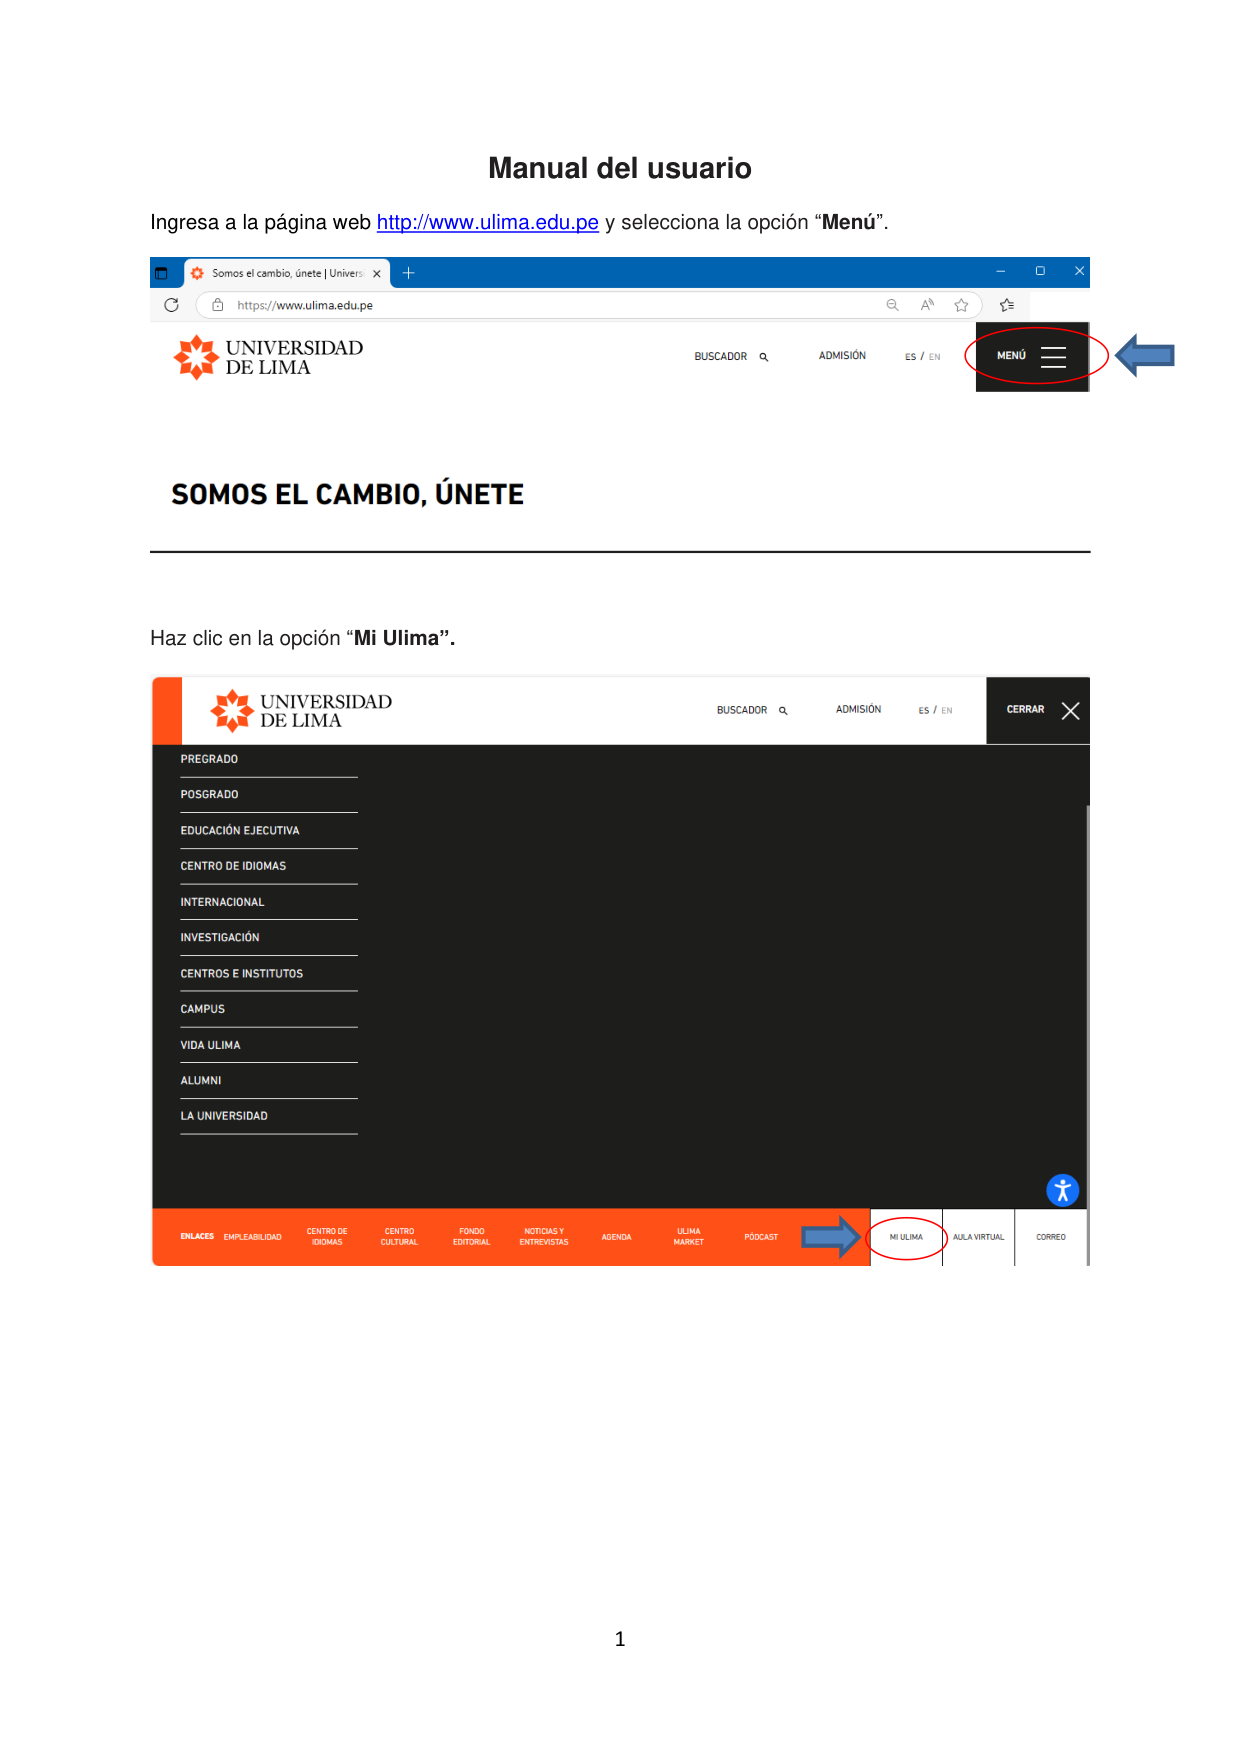

## Paso 1: Ingresar a la web y abrir el menú

**Instrucción:** Ingresa a la página web http://www.ulima.edu.pe y selecciona la opción “Menú”.

**Descripción de la interfaz:**
- Botón **“MENÚ”** (esquina superior derecha), junto a un **ícono de tres líneas horizontales** (menú hamburguesa).

**Anotaciones visuales:** 
- **Óvalo rojo** rodeando el botón **“MENÚ”** y el ícono de **tres líneas**.
- **Flecha azul** apuntando **hacia la izquierda** al área del botón **“MENÚ”** (desde el lado derecho hacia el botón).

**Acción requerida:** Ingresar a **http://www.ulima.edu.pe** y hacer clic en **“Menú”**.

---

## Paso 2: Seleccionar la opción “Mi Ulima”

**Instrucción:** Haz clic en la opción “Mi Ulima”.

**Descripción de la interfaz:**
- Barra inferior con opciones (zona inferior de la pantalla); entre ellas, el enlace/botón **“MI ULIMA”** (hacia la parte inferior derecha, dentro de una sección clara contigua a la barra naranja).
- Elemento de cierre del panel: texto **“CERRAR”** (esquina superior derecha del panel desplegado) con un ícono **“X”** a su derecha. [Elemento de referencia visual]

**Anotaciones visuales:** 
- **Óvalo rojo** rodeando el texto **“MI ULIMA”**.
- **Flecha azul** apuntando **hacia la derecha** al área del enlace **“MI ULIMA”** (desde la izquierda hacia el botón).

**Acción requerida:** Hacer clic en **“Mi Ulima”**.

---

## Palabras clave
Manual del usuario, http://www.ulima.edu.pe, Menú, MENÚ, Mi Ulima, MI ULIMA, CERRAR, X, Universidad de Lima, menú hamburguesa, clic, opción, enlace, barra inferior, panel desplegado

## Paso 1: Ingresar a la web y abrir el menú

**Instrucción:** Ingresa a la página web http://www.ulima.edu.pe y selecciona la opción “Menú”.

**Descripción de la interfaz:**
- Botón **“MENÚ”** (esquina superior derecha), junto a un **ícono de tres líneas horizontales** (menú hamburguesa).

**Anotaciones visuales:** 
- **Óvalo rojo** rodeando el botón **“MENÚ”** y el ícono de **tres líneas**.
- **Flecha azul** apuntando **hacia la izquierda** al área del botón **“MENÚ”** (desde el lado derecho hacia el botón).

**Acción requerida:** Ingresar a **http://www.ulima.edu.pe** y hacer clic en **“Menú”**.

---

## Paso 2: Seleccionar la opción “Mi Ulima”

**Instrucción:** Haz clic en la opción “Mi Ulima”.

**Descripción de la interfaz:**
- Barra inferior con opciones (zona inferior de la pantalla); entre ellas, el enlace/botón **“MI ULIMA”** (hacia la parte inferior derecha, dentro de una sección clara contigua a la barra naranja).
- Elemento de cierre del panel: texto **“CERRAR”** (esquina s

In [ ]:
TEST_PAGE = 1   # ← Cambia al número de página a probar

assert 1 <= TEST_PAGE <= len(pages), f"Rango válido: 1–{len(pages)}"

print(f"🔍 Probando prompt en página {TEST_PAGE}...\n")
test_result = call_openai(pages[TEST_PAGE - 1], SYSTEM_PROMPT)

display(HTML(
    f'<h4 style="font-family:sans-serif;color:#444">🖼️ Imagen — Página {TEST_PAGE}</h4>'
))
display(IPImage(data=img_to_bytes(pages[TEST_PAGE - 1]), width=700))
display(HTML("<hr style='margin:20px 0;border-color:#dee2e6'>"))
display(HTML(
    f'<h4 style="font-family:sans-serif;color:#1a73e8">'
    f'📝 Output del modelo — {MODEL} (renderizado)</h4>'
))
display(Markdown(test_result))
display(HTML("<hr style='margin:20px 0;border-color:#dee2e6'>"))
display(HTML('<h4 style="font-family:sans-serif;color:#444">📋 Markdown crudo</h4>'))
print(test_result)


## ⚡ Sección 5 — Procesamiento Batch (todas las páginas)

> Ejecuta esta celda y espera. Procesa todas las páginas en secuencia.  
> Las páginas fallidas quedan marcadas con `<!-- ERROR -->` en el `.md` final.  
> Al terminar, el resumen muestra cuántas fueron exitosas y cuánto tardó.


In [ ]:
results      = {}   # {num_pagina: markdown_string}
failed_pages = []   # páginas que fallaron definitivamente
start_time   = datetime.now()

print(f"{'═'*60}")
print(f"  ⚡ Iniciando batch — {len(pages)} páginas · Modelo: {MODEL}")
print(f"  Inicio: {start_time.strftime('%H:%M:%S')}")
print(f"{'═'*60}\n")

for i, img in enumerate(pages):
    page_num  = i + 1
    page_start = time.time()

    print(f"  [{page_num:02d}/{len(pages):02d}] Procesando...", end=" ", flush=True)

    md = call_with_retry(img, page_num)
    results[page_num] = md

    elapsed = time.time() - page_start
    if md.startswith("<!-- ERROR"):
        failed_pages.append(page_num)
        print(f"❌  ({elapsed:.1f}s)")
    else:
        words = len(md.split())
        print(f"✅  {words} palabras  ({elapsed:.1f}s)")

    # Pausa entre páginas (excepto la última)
    if DELAY_BETWEEN_PAGES > 0 and i < len(pages) - 1:
        time.sleep(DELAY_BETWEEN_PAGES)

# ── Resumen final ─────────────────────────────────────────────
end_time      = datetime.now()
total_elapsed = (end_time - start_time).total_seconds()
ok_count      = len(pages) - len(failed_pages)

print(f"\n{'═'*60}")
print(f"  ✅ Completado: {ok_count}/{len(pages)} páginas exitosas")
if failed_pages:
    print(f"  ❌ Fallidas  : {failed_pages}")
print(f"  ⏱️  Tiempo total: {total_elapsed:.0f}s  "
      f"({total_elapsed/len(pages):.1f}s/página promedio)")
print(f"  Fin: {end_time.strftime('%H:%M:%S')}")
print(f"{'═'*60}")
print(f"\n▶ Ejecuta la Sección 6 para exportar el archivo .md")


════════════════════════════════════════════════════════════
  ⚡ Iniciando batch — 17 páginas · Modelo: gpt-5.2
  Inicio: 20:36:40
════════════════════════════════════════════════════════════

  [01/17] Procesando... ✅  200 palabras  (5.5s)
  [02/17] Procesando... ✅  570 palabras  (12.9s)
  [03/17] Procesando... ✅  449 palabras  (10.9s)
  [04/17] Procesando... ✅  376 palabras  (7.9s)
  [05/17] Procesando... ✅  383 palabras  (8.2s)
  [06/17] Procesando... ✅  332 palabras  (9.0s)
  [07/17] Procesando... ✅  416 palabras  (9.3s)
  [08/17] Procesando... ✅  421 palabras  (11.1s)
  [09/17] Procesando... ✅  746 palabras  (13.9s)
  [10/17] Procesando... ✅  395 palabras  (8.4s)
  [11/17] Procesando... ✅  218 palabras  (5.4s)
  [12/17] Procesando... ✅  403 palabras  (8.4s)
  [13/17] Procesando... ✅  272 palabras  (6.3s)
  [14/17] Procesando... ✅  472 palabras  (9.6s)
  [15/17] Procesando... ✅  398 palabras  (8.6s)
  [16/17] Procesando... ✅  581 palabras  (10.1s)
  [17/17] Procesando... ✅  251 pal

## 📤 Sección 6 — Exportar `.md` combinado

In [ ]:
if not results:
    print("⚠️  No hay resultados. Ejecuta primero la Sección 5.")
else:
    # ── Construir el Markdown combinado ───────────────────────
    lines = [
        "# Manual de Usuario — Conversión Visual a Markdown",
        f"<!-- pipeline: visual-to-markdown-rag · modelo: {MODEL} -->",
        f"<!-- páginas: {len(results)}/{len(pages)} -->",
        f"<!-- generado: {datetime.now().strftime('%Y-%m-%d %H:%M')} -->",
        "",
    ]

    for num in sorted(results.keys()):
        lines += [
            f"<!-- ===== INICIO PÁGINA {num:02d} ===== -->",
            f"<!-- page_number: {num} -->",
            "",
            results[num],
            "",
            "---",
            "",
        ]

    combined_md = "\n".join(lines)

    # ── Guardar y descargar ───────────────────────────────────
    out_file = f"manual_rag_{datetime.now().strftime('%Y%m%d_%H%M%S')}.md"
    with open(out_file, "w", encoding="utf-8") as f:
        f.write(combined_md)

    print(f"✅ Archivo generado: {out_file}")
    print(f"   Páginas incluidas  : {len(results)}")
    if failed_pages:
        print(f"   ⚠️  Páginas con error: {failed_pages}  (marcadas con <!-- ERROR --> en el .md)")
    print(f"   Tamaño total       : {len(combined_md):,} caracteres")
    print("\n⬇️  Iniciando descarga...")
    files.download(out_file)

    print(f"\n{'─'*60}")
    print("📄 Preview (primeras 40 líneas):")
    print('─'*60)
    for line in combined_md.split("\n")[:40]:
        print(line)


✅ Archivo generado: manual_rag_20260603_203928.md
   Páginas incluidas  : 17
   Tamaño total       : 50,524 caracteres

⬇️  Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


────────────────────────────────────────────────────────────
📄 Preview (primeras 40 líneas):
────────────────────────────────────────────────────────────
# Manual de Usuario — Conversión Visual a Markdown
<!-- pipeline: visual-to-markdown-rag · modelo: gpt-5.2 -->
<!-- páginas: 17/17 -->
<!-- generado: 2026-06-03 20:39 -->

<!-- ===== INICIO PÁGINA 01 ===== -->
<!-- page_number: 1 -->

## Paso 1: Ingresar al sitio web y seleccionar “Menú”

**Instrucción:** Ingresa a la página web http://www.ulima.edu.pe y selecciona la opción “Menú”.

**Descripción de la interfaz:**
- Opción **“MENÚ”**: botón ubicado en la parte superior derecha de la página, junto a un ícono de tres líneas horizontales (menú hamburguesa).

**Anotaciones visuales:** 
- **Círculo rojo**: rodea el botón **“MENÚ”** y el ícono de menú (tres líneas) en la esquina superior derecha.
- **Flecha azul**: apunta desde la derecha hacia la izquierda, señalando directamente el botón **“MENÚ”** dentro del círculo rojo.

**Acción req